In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
#Simple Linear Regression 
#From: https://www.geeksforgeeks.org/machine-learning/linear-regression-python-implementation/
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  
   
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

In [3]:
dfMonth=pd.read_csv("../DataFrames/tempByMonth.csv", index_col='Unnamed: 0')
print(dfMonth.head())



     Month  Year    TempAvg
0  January  1869  34.596774
1  January  1870  37.693548
2  January  1871  27.838710
3  January  1872  29.129032
4  January  1873  27.354839


Simple LR Coefficients:  [4.53556964e+01 9.39556397e-03]
R2 Score:  0.09658646059797649


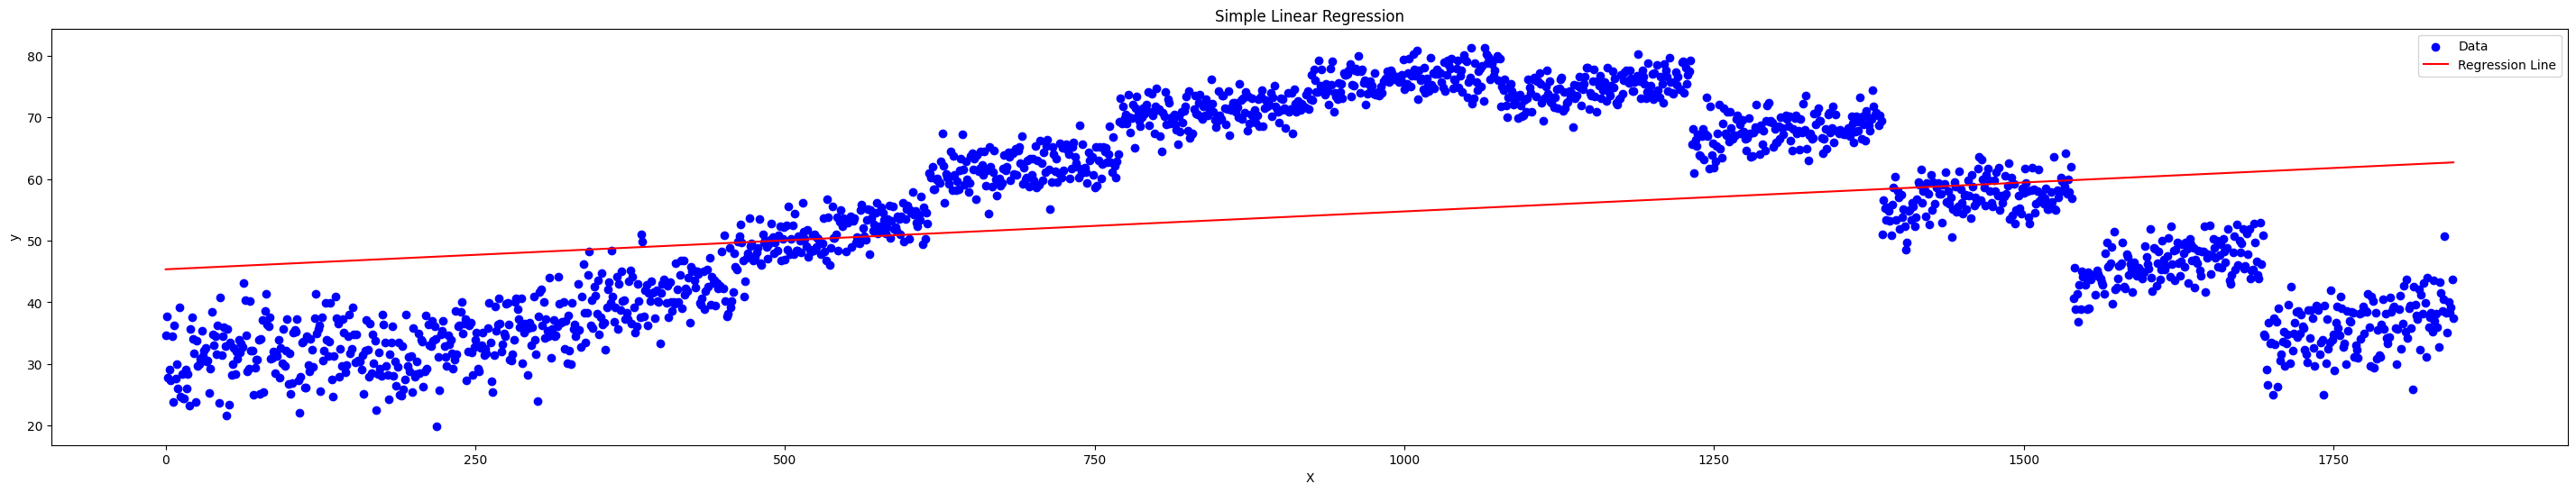

In [4]:
#For Month
X=np.array(dfMonth.index).reshape(-1, 1)
y=np.array(dfMonth['TempAvg'])

slrMonth=SimpleLinearRegression()
slrMonth.fit(X, y)

print("Simple LR Coefficients: ", slrMonth.coefficients_)
print("R2 Score: ", slrMonth.r2score_)

plt.figure(figsize=(36, 6))

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, slrMonth.y_pred_, color='red', label='Regression Line')

plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()



In [5]:
dfYear=pd.read_csv("../DataFrames/tempByYear.csv", index_col='Unnamed: 0')
print(dfYear.head())

   Year    TempAvg
0  1869  51.809012
1  1870  53.690351
2  1871  51.302631
3  1872  51.320184
4  1873  50.779887


Simple LR Coefficients:  [5.18587533e+01 2.84149853e-02]
R2 Score:  0.5519866974171408


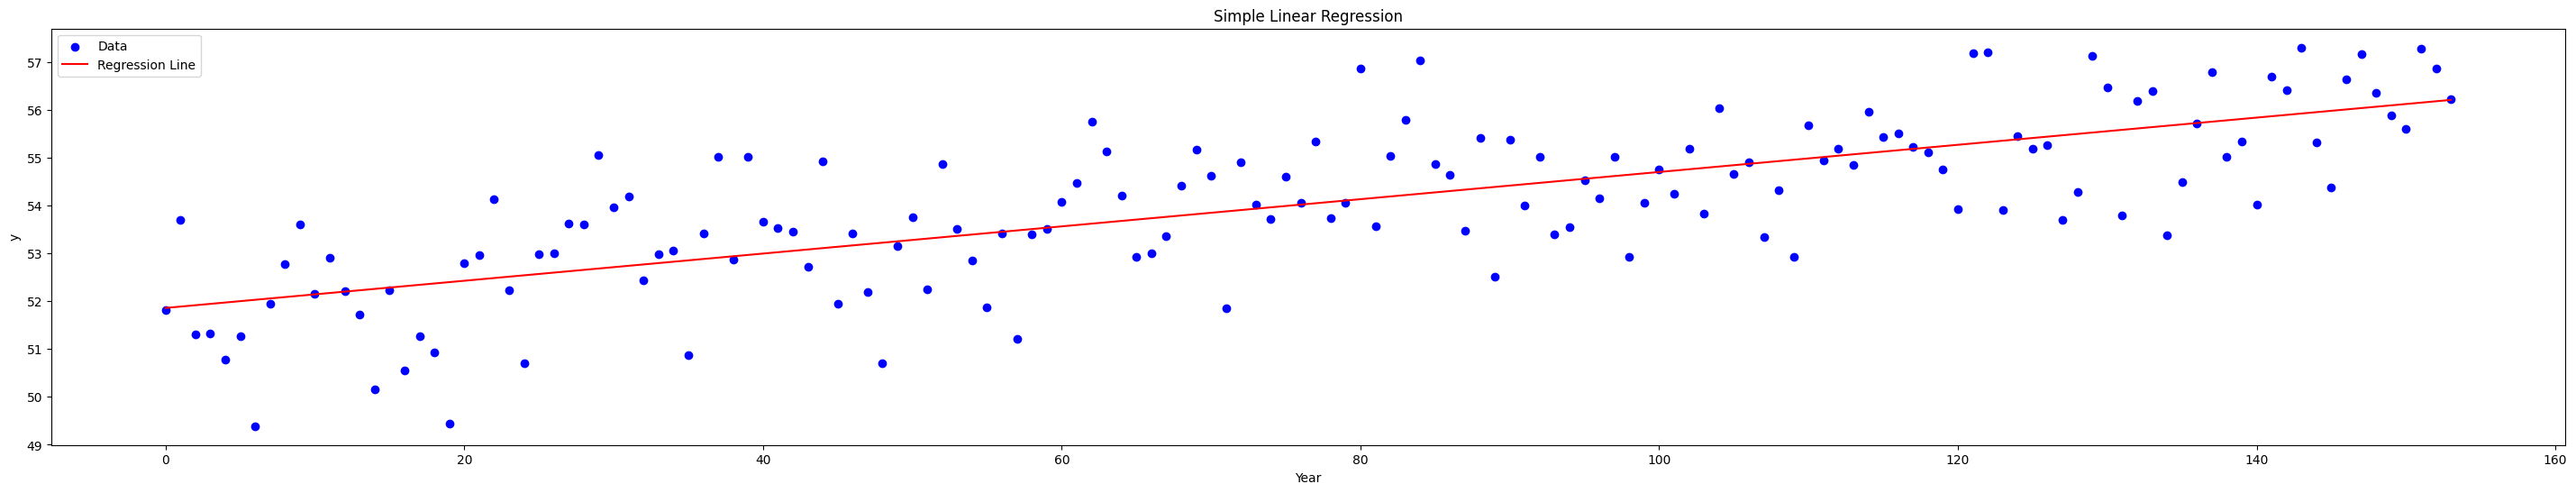

In [6]:
#For Year
Xyear=np.array(dfYear.index).reshape(-1, 1)
yYear=np.array(dfYear['TempAvg'])

slrYear=SimpleLinearRegression()
slrYear.fit(Xyear, yYear)

print("Simple LR Coefficients: ", slrYear.coefficients_)
print("R2 Score: ", slrYear.r2score_)

plt.figure(figsize=(36, 6))

plt.scatter(Xyear, yYear, color='blue', label='Data')
plt.plot(Xyear, slrYear.y_pred_, color='red', label='Regression Line')

plt.title("Simple Linear Regression")
plt.xlabel("Year")
plt.ylabel("y")
plt.legend()
plt.show()

